# Greenwashing Radar
## COM2019 Final Assessment – Jupyter Notebook

This notebook implements a prompt-engineered system for detecting sustainability claims and possible greenwashing risk from product text and packaging images.

It compares:
1. A heuristic text baseline
2. A text-only LLM system
3. A multimodal LLM system

It also includes:
- structured JSON outputs
- error handling and retries
- LLM-as-judge evaluation
- optional manual gold-set evaluation

**Installing packages**

In [1]:
!pip install -q openai openfoodfacts==5.0.1 pandas numpy matplotlib scikit-learn tqdm ipython

## 1. Imports, configuration, and helper functions

**Importing Libraries**

In [2]:
import re 
import requests 
import os
import json
import time
import random
import logging
from typing import Any, Dict, List, Optional

import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

from openai import OpenAI
from openfoodfacts import API, APIVersion, Country, Environment, Flavor


**A. API KEY AND MODEL SETTINGS**

Important: Put your real API key.

In [3]:
OPENAI_API_KEY = "API_key_here"

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
client = OpenAI()

MODEL_TEXT = os.getenv("OPENAI_MODEL_TEXT", "gpt-4.1-mini")
MODEL_MM = os.getenv("OPENAI_MODEL_MM", "gpt-4.1-mini")
MODEL_JUDGE = os.getenv("OPENAI_MODEL_JUDGE", "gpt-4.1-mini")

**B. OPEN FOOD FACTS API SETUP**

In [4]:
off_api = API(
    user_agent="COM2019-GreenwashingRadar/1.0",
    country=Country.world,
    flavor=Flavor.off,
    version=APIVersion.v2,
    environment=Environment.org,
)

**C. PROJECT FOLDERS**

In [5]:
PROJECT_NAME = "greenwashing_radar"
DATA_DIR = "project_data"
RESULTS_DIR = "project_results"
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

for folder in [DATA_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(folder, exist_ok=True)

**D. LOGGING AND REPRODUCIBILITY**

In [6]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(PROJECT_NAME)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

**E. EXPERIMENT SETTINGS**

In [7]:
SAMPLE_SIZE = 24

MAX_PRODUCTS_PER_QUERY = 20
REQUEST_DELAY_SECONDS = 2.5
MAX_RETRIES = 4

SEARCH_TERMS = [
    "recyclable",
    "recycled",
    "organic",
    "natural",
    "biodegradable",
    "compostable",
    "plant based",
    "vegan"
]

FALLBACK_NEUTRAL_TERMS = [
    "pasta",
    "coffee",
    "biscuits",
    "juice"
]

**F. SMALL TEXT HELPERS**

In [8]:
def safe_text(value: Any) -> str:
    if value is None:
        return ""
    return str(value).strip()

def join_nonempty(parts: List[str], sep: str = " | ") -> str:
    clean = [safe_text(p) for p in parts if safe_text(p)]
    return sep.join(clean)

def build_product_text(product: Dict[str, Any]) -> str:
    return join_nonempty(
        [
            f"Product name: {product.get('product_name', '')}",
            f"Brand: {product.get('brands', '')}",
            f"Generic name: {product.get('generic_name', '')}",
            f"Ingredients: {product.get('ingredients_text', '')}",
            f"Labels: {product.get('labels', '')}",
            f"Categories: {product.get('categories', '')}",
            f"Packaging: {product.get('packaging', '')}",
        ],
        sep="\n"
    )

def is_valid_image_url(url: str) -> bool:
    url = safe_text(url)
    return url.startswith("http://") or url.startswith("https://")

def first_image_url(product: Dict[str, Any]) -> str:
    for key in ["image_front_url", "image_url", "image_small_url"]:
        candidate = safe_text(product.get(key))
        if is_valid_image_url(candidate):
            return candidate
    return ""

def product_to_row(product: Dict[str, Any], query: str) -> Dict[str, Any]:
    text_blob = build_product_text(product)
    image_url = first_image_url(product)

    return {
        "query": query,
        "code": safe_text(product.get("code")),
        "product_name": safe_text(product.get("product_name")),
        "brands": safe_text(product.get("brands")),
        "generic_name": safe_text(product.get("generic_name")),
        "ingredients_text": safe_text(product.get("ingredients_text")),
        "labels": safe_text(product.get("labels")),
        "categories": safe_text(product.get("categories")),
        "packaging": safe_text(product.get("packaging")),
        "image_url": image_url,
        "text_blob": text_blob,
        "ecoscore_grade": safe_text(product.get("ecoscore_grade")),
        "nutriscore_grade": safe_text(product.get("nutriscore_grade")),
        "product_page_url": safe_text(product.get("url")),
        "has_image": bool(image_url),
        "text_length": len(text_blob),
    }

**G. OPEN FOOD FACTS COLLECTION**

In [9]:
CACHE_DIR = os.path.join(DATA_DIR, "off_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

OFF_FIELDS = [
    "code",
    "product_name",
    "brands",
    "generic_name",
    "ingredients_text",
    "labels",
    "categories",
    "packaging",
    "image_front_url",
    "image_url",
    "image_small_url",
    "ecoscore_grade",
    "nutriscore_grade",
    "url",
]

def _query_to_cache_name(query: str) -> str:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", query.strip().lower())
    return os.path.join(CACHE_DIR, f"{safe}.json")

def off_search(query: str) -> List[Dict[str, Any]]:
    """
    Robust Open Food Facts search with:
    - direct requests
    - cache
    - retries
    - graceful failure
    """
    cache_path = _query_to_cache_name(query)

    # Use cache if already available
    if os.path.exists(cache_path):
        try:
            with open(cache_path, "r", encoding="utf-8") as f:
                cached = json.load(f)
            logger.info(f"Loaded cached Open Food Facts results for query='{query}'")
            return cached
        except Exception as exc:
            logger.warning(f"Could not read cache for query='{query}': {exc}")

    url = "https://world.openfoodfacts.org/cgi/search.pl"
    params = {
        "search_terms": query,
        "search_simple": 1,
        "action": "process",
        "json": 1,
        "page_size": MAX_PRODUCTS_PER_QUERY,
        "fields": ",".join(OFF_FIELDS),
    }
    headers = {
        "User-Agent": "COM2019-GreenwashingRadar/1.0"
    }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.get(
                url,
                params=params,
                headers=headers,
                timeout=45
            )

            # Explicit handling for temporary server issues
            if response.status_code == 503:
                raise requests.HTTPError(
                    f"503 Service Temporarily Unavailable for query='{query}'",
                    response=response
                )

            response.raise_for_status()

            data = response.json()
            products = data.get("products", [])

            # Save cache
            try:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump(products, f, ensure_ascii=False, indent=2)
            except Exception as exc:
                logger.warning(f"Could not write cache for query='{query}': {exc}")

            time.sleep(REQUEST_DELAY_SECONDS)
            logger.info(f"Query='{query}' returned {len(products)} products")
            return products

        except Exception as exc:
            wait_seconds = min(5 * attempt, 25)
            logger.warning(
                f"Open Food Facts search failed for query='{query}' "
                f"attempt={attempt}/{MAX_RETRIES}: {exc}"
            )
            if attempt < MAX_RETRIES:
                time.sleep(wait_seconds)

    logger.error(f"Skipping query='{query}' after repeated failures.")
    return []

def collect_products(search_terms: List[str], neutral_terms: Optional[List[str]] = None) -> pd.DataFrame:
    records: List[Dict[str, Any]] = []

    for query in search_terms:
        products = off_search(query)
        if not products:
            logger.warning(f"No products collected for query='{query}'")
            continue

        for product in products:
            records.append(product_to_row(product, query=query))

    if neutral_terms:
        for query in neutral_terms:
            products = off_search(query)
            if not products:
                logger.warning(f"No products collected for neutral query='{query}'")
                continue

            for product in products:
                records.append(product_to_row(product, query=f"neutral::{query}"))

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError(
            "No products were collected from Open Food Facts. "
            "This is likely due to a temporary Open Food Facts outage or blocking. "
            "Wait 10-20 minutes and rerun the notebook."
        )

  
    # SMALL FILTER FOR BETTER CLAIM-RELATED DATA QUALITY
   
    claim_keywords = [
        "recycl",
        "organic",
        "natural",
        "eco",
        "sustain",
        "biodegrad",
        "compost",
        "plant based",
        "vegan",
        "carbon neutral",
        "plastic free"
    ]

    text_for_filter = (
        df["product_name"].fillna("") + " " +
        df["labels"].fillna("") + " " +
        df["generic_name"].fillna("") + " " +
        df["packaging"].fillna("") + " " +
        df["ingredients_text"].fillna("")
    ).str.lower()

    claim_mask = text_for_filter.apply(lambda x: any(k in x for k in claim_keywords))

    # Keep only claim-seeded rows that actually look relevant,
    # but keep all neutral rows unchanged
    claim_rows = df[~df["query"].str.startswith("neutral::")].copy()
    neutral_rows = df[df["query"].str.startswith("neutral::")].copy()

    claim_rows = claim_rows[claim_mask[claim_rows.index]]

    df = pd.concat([claim_rows, neutral_rows], ignore_index=True)

    
    # NORMAL CLEANING
   
    df = df.drop_duplicates(subset=["code"])
    df = df[df["code"].astype(str).str.len() > 0].copy()

    df["claim_seed"] = ~df["query"].str.startswith("neutral::")
    df["has_text"] = df["text_blob"].str.len() > 40
    df["usable"] = df["has_text"] & df["has_image"]

    df = df.sort_values(
        ["usable", "claim_seed", "text_length"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    logger.info(f"Collected {len(df)} unique products in total")
    return df

def balanced_sample(df: pd.DataFrame, n: int = SAMPLE_SIZE) -> pd.DataFrame:
    usable_claim = df[(df["claim_seed"]) & (df["usable"])].copy()
    usable_neutral = df[(~df["claim_seed"]) & (df["usable"])].copy()

    n_claim = max(n // 2, 1)
    n_neutral = max(n - n_claim, 1)

    claim_sample = usable_claim.head(n_claim)
    neutral_sample = usable_neutral.head(n_neutral)

    sample = pd.concat([claim_sample, neutral_sample], ignore_index=True)

    if len(sample) < n:
        remaining = df[~df["code"].isin(sample["code"])].head(n - len(sample))
        sample = pd.concat([sample, remaining], ignore_index=True)

    if sample.empty:
        raise ValueError(
            "No usable sample could be created. "
            "Try rerunning later, or reduce SAMPLE_SIZE to 4."
        )

    if len(sample) < n:
        logger.warning(
            f"Only {len(sample)} products available for sampling, less than requested n={n}."
        )

    sample = sample.head(n).copy()
    sample["sample_id"] = [f"P{i:03d}" for i in range(1, len(sample) + 1)]

    return sample

**H. STRUCTURED OUTPUT SCHEMA**

In [10]:
SCHEMA = {
    "type": "object",
    "properties": {
        "claim_detected": {"type": "boolean"},
        "claim_modalities": {
            "type": "array",
            "items": {"type": "string", "enum": ["text", "image"]}
        },
        "claim_types": {
            "type": "array",
            "items": {
                "type": "string",
                "enum": [
                    "recycled_material",
                    "recyclable",
                    "compostable_or_biodegradable",
                    "organic_or_natural",
                    "plant_based",
                    "carbon_or_climate",
                    "packaging_reduction",
                    "certification_or_label",
                    "vague_eco_language",
                    "visual_nature_cue",
                    "other"
                ]
            }
        },
        "specificity": {
            "type": "string",
            "enum": ["none", "specific", "mixed", "vague"]
        },
        "evidence_strength": {
            "type": "string",
            "enum": ["none", "weak", "moderate", "strong"]
        },
        "risk_score": {
            "type": "integer",
            "minimum": 0,
            "maximum": 5
        },
        "risk_label": {
            "type": "string",
            "enum": ["none", "low", "medium", "high"]
        },
        "evidence": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "modality": {"type": "string", "enum": ["text", "image"]},
                    "snippet": {"type": "string"},
                    "explanation": {"type": "string"}
                },
                "required": ["modality", "snippet", "explanation"],
                "additionalProperties": False
            }
        },
        "reasoning_summary": {"type": "string"},
        "needs_human_check": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": [
        "claim_detected",
        "claim_modalities",
        "claim_types",
        "specificity",
        "evidence_strength",
        "risk_score",
        "risk_label",
        "evidence",
        "reasoning_summary",
        "needs_human_check"
    ],
    "additionalProperties": False
}


**I. PROMPTS**

In [11]:
SYSTEM_PROMPT = """
You are a sustainability-claims auditor for a university assessment.
Your job is not to accuse brands of deception.
Your job is to identify environmental or sustainability-related marketing claims or cues,
judge how specific they are, and estimate greenwashing risk conservatively.

Important rules:
1. Only use information that is explicitly present in the supplied text or visible in the image.
2. Do not invent certifications, ingredients, or evidence.
3. Green colours, leaves, and natural imagery alone are not enough for a high risk score.
4. Risk should increase when claims are vague, broad, unverifiable, or unsupported.
5. Specific, measurable, limited claims should reduce risk.
6. If no sustainability claim or cue is present, return no claim and a risk score of 0.
7. Use the image only for what is visible on the packaging.
""".strip()

def build_user_prompt(text_only: bool = False) -> str:
    if text_only:
        return """
Analyse the product text and return a structured JSON assessment.

Scoring guide:
- 0 = no sustainability claim or cue
- 1 = weak or indirect cue only
- 2 = low concern, limited claim or weak nature-positioning
- 3 = moderate concern, claim exists but is vague or weakly supported
- 4 = high concern, broad claim with little visible substantiation
- 5 = very high concern, strong sweeping claim with no visible support

Be conservative.
""".strip()

    return """
Analyse BOTH the product text and the packaging image and return a structured JSON assessment.

Use this sequence:
A. Identify explicit sustainability claims in text and image.
B. Identify implicit sustainability cues, but do not over-interpret nature styling.
C. Judge specificity and visible support.
D. Assign a conservative risk score.

Scoring guide:
- 0 = no sustainability claim or cue
- 1 = weak or indirect cue only
- 2 = low concern, limited claim or weak nature-positioning
- 3 = moderate concern, claim exists but is vague or weakly supported
- 4 = high concern, broad claim with little visible substantiation
- 5 = very high concern, strong sweeping claim with no visible support

Be conservative and evidence-led.
""".strip()

def parse_json_text(text: str) -> Dict[str, Any]:
    return json.loads(text.strip())

**J. OPENAI INFERENCE FUNCTIONS**

In [12]:
def openai_assess_product(
    product_row: pd.Series,
    use_image: bool = True,
    model: str = MODEL_MM,
    max_output_tokens: int = 1000
) -> Dict[str, Any]:

    text_payload = product_row["text_blob"]
    image_url = safe_text(product_row.get("image_url", ""))

    content_blocks: List[Dict[str, Any]] = [
        {
            "type": "input_text",
            "text": f"Sample ID: {product_row['sample_id']}\n\nProduct data:\n{text_payload}"
        }
    ]

    if use_image and is_valid_image_url(image_url):
        content_blocks.append(
            {
                "type": "input_image",
                "image_url": image_url,
                "detail": "high"
            }
        )

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.responses.create(
                model=model,
                temperature=0,
                max_output_tokens=max_output_tokens,
                input=[
                    {
                        "role": "system",
                        "content": [
                            {"type": "input_text", "text": SYSTEM_PROMPT}
                        ]
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": build_user_prompt(text_only=not use_image)},
                            *content_blocks
                        ]
                    }
                ],
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "greenwashing_assessment",
                        "strict": True,
                        "schema": SCHEMA
                    }
                }
            )
            return parse_json_text(response.output_text)

        except Exception as exc:
            wait_seconds = min(2 ** attempt, 20)
            logger.warning(
                f"OpenAI call failed for {product_row['sample_id']} | use_image={use_image} | attempt={attempt} | {exc}"
            )
            if attempt == MAX_RETRIES:
                raise
            time.sleep(wait_seconds)

    raise RuntimeError("OpenAI call failed after retries.")

**K. RULE-BASED BASELINE**

In [13]:
EXPLICIT_KEYWORDS = {
    "recycled_material": ["100% recycled", "recycled material", "made from recycled"],
    "recyclable": ["recyclable", "please recycle", "widely recycled"],
    "compostable_or_biodegradable": ["compostable", "biodegradable"],
    "organic_or_natural": ["organic", "all natural", "natural", "naturally"],
    "plant_based": ["plant based", "plant-based", "vegan"],
    "carbon_or_climate": ["carbon neutral", "net zero", "climate neutral"],
    "packaging_reduction": ["plastic free", "less plastic", "reduced packaging"],
    "certification_or_label": ["fsc", "fairtrade", "eu organic", "rainforest alliance"],
    "vague_eco_language": [
        "eco",
        "eco-friendly",
        "environmentally friendly",
        "planet friendly",
        "green choice"
    ]
}

def heuristic_baseline(text_blob: str) -> Dict[str, Any]:
    text = safe_text(text_blob).lower()
    claim_types = []
    evidence = []

    for claim_type, keywords in EXPLICIT_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                claim_types.append(claim_type)
                evidence.append(
                    {
                        "modality": "text",
                        "snippet": kw,
                        "explanation": "Keyword matched in product text."
                    }
                )
                break

    claim_detected = len(claim_types) > 0

    if not claim_detected:
        return {
            "claim_detected": False,
            "claim_modalities": [],
            "claim_types": [],
            "specificity": "none",
            "evidence_strength": "none",
            "risk_score": 0,
            "risk_label": "none",
            "evidence": [],
            "reasoning_summary": "No sustainability keyword detected by heuristic baseline.",
            "needs_human_check": []
        }

    vague_terms = {"vague_eco_language", "organic_or_natural"}
    specificity = "vague" if any(c in vague_terms for c in claim_types) else "specific"
    risk_score = 3 if specificity == "vague" else 2
    risk_label = "medium" if risk_score >= 3 else "low"

    return {
        "claim_detected": True,
        "claim_modalities": ["text"],
        "claim_types": claim_types,
        "specificity": specificity,
        "evidence_strength": "weak",
        "risk_score": risk_score,
        "risk_label": risk_label,
        "evidence": evidence[:3],
        "reasoning_summary": "Heuristic baseline matched sustainability-related keywords in text.",
        "needs_human_check": [
            "Heuristic baseline may miss image-only cues and nuanced wording."
        ]
    }

**L. RESULT FLATTENING AND EXPERIMENT RUNNER**

In [14]:
def flatten_assessment(sample_id: str, method: str, assessment: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "sample_id": sample_id,
        "method": method,
        "claim_detected": assessment.get("claim_detected"),
        "claim_modalities": json.dumps(assessment.get("claim_modalities", []), ensure_ascii=False),
        "claim_types": json.dumps(assessment.get("claim_types", []), ensure_ascii=False),
        "specificity": assessment.get("specificity"),
        "evidence_strength": assessment.get("evidence_strength"),
        "risk_score": assessment.get("risk_score"),
        "risk_label": assessment.get("risk_label"),
        "evidence_count": len(assessment.get("evidence", [])),
        "reasoning_summary": assessment.get("reasoning_summary"),
        "needs_human_check": json.dumps(assessment.get("needs_human_check", []), ensure_ascii=False),
        "raw_json": json.dumps(assessment, ensure_ascii=False),
    }

def run_experiments(sample_df: pd.DataFrame) -> pd.DataFrame:
    records: List[Dict[str, Any]] = []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Running experiments"):
        baseline_result = heuristic_baseline(row["text_blob"])
        records.append(flatten_assessment(row["sample_id"], "heuristic_text", baseline_result))

        text_result = openai_assess_product(row, use_image=False, model=MODEL_TEXT)
        records.append(flatten_assessment(row["sample_id"], "llm_text", text_result))

        mm_result = openai_assess_product(row, use_image=True, model=MODEL_MM)
        records.append(flatten_assessment(row["sample_id"], "llm_multimodal", mm_result))

    return pd.DataFrame(records)

**M. LLM-AS-JUDGE EVALUATION**

In [15]:
JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "groundedness_score": {"type": "integer", "minimum": 1, "maximum": 5},
        "conservatism_score": {"type": "integer", "minimum": 1, "maximum": 5},
        "explanation_quality_score": {"type": "integer", "minimum": 1, "maximum": 5},
        "judge_summary": {"type": "string"}
    },
    "required": [
        "groundedness_score",
        "conservatism_score",
        "explanation_quality_score",
        "judge_summary"
    ],
    "additionalProperties": False
}

JUDGE_SYSTEM_PROMPT = """
You are evaluating an AI system used in a university assignment.
Score the output, not the product.
Be strict and concise.
""".strip()

def judge_output(product_row: pd.Series, raw_json: str, model: str = MODEL_JUDGE) -> Dict[str, Any]:
    judge_prompt = f"""
Product text:
{product_row['text_blob']}

Image URL:
{product_row['image_url']}

Model output JSON:
{raw_json}

Evaluate the output on:
1. groundedness in visible input
2. conservatism / not over-claiming
3. explanation quality

Return JSON only.
""".strip()

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.responses.create(
                model=model,
                temperature=0,
                max_output_tokens=500,
                input=[
                    {
                        "role": "system",
                        "content": [
                            {"type": "input_text", "text": JUDGE_SYSTEM_PROMPT}
                        ]
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": judge_prompt}
                        ]
                    }
                ],
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "judge_scores",
                        "strict": True,
                        "schema": JUDGE_SCHEMA
                    }
                }
            )
            return parse_json_text(response.output_text)

        except Exception as exc:
            wait_seconds = min(2 ** attempt, 20)
            logger.warning(f"Judge call failed for {product_row['sample_id']} attempt={attempt}: {exc}")
            if attempt == MAX_RETRIES:
                raise
            time.sleep(wait_seconds)

    raise RuntimeError("Judge call failed after retries.")

def run_judge(sample_df: pd.DataFrame, results_df: pd.DataFrame, method: str = "llm_multimodal") -> pd.DataFrame:
    method_df = results_df[results_df["method"] == method].copy()
    judge_rows = []

    for _, result_row in tqdm(method_df.iterrows(), total=len(method_df), desc=f"Judging {method}"):
        product_row = sample_df[sample_df["sample_id"] == result_row["sample_id"]].iloc[0]
        scores = judge_output(product_row, result_row["raw_json"], model=MODEL_JUDGE)
        judge_rows.append(
            {
                "sample_id": result_row["sample_id"],
                "method": method,
                **scores
            }
        )

    return pd.DataFrame(judge_rows)

**N. OPTIONAL HUMAN GOLD SET**

In [16]:
def create_annotation_template(sample_df: pd.DataFrame) -> pd.DataFrame:
    template = sample_df[[
        "sample_id",
        "product_name",
        "brands",
        "query",
        "text_blob",
        "image_url"
    ]].copy()

    template["gold_claim_detected"] = ""
    template["gold_specificity"] = ""
    template["gold_risk_score"] = ""
    template["gold_notes"] = ""

    return template

def load_gold_annotations(path: str) -> pd.DataFrame:
    gold = pd.read_csv(path)

    gold["gold_claim_detected"] = gold["gold_claim_detected"].map(
        {
            "TRUE": True,
            "FALSE": False,
            "True": True,
            "False": False,
            True: True,
            False: False
        }
    )

    gold["gold_specificity"] = gold["gold_specificity"].astype(str).str.strip().str.lower()
    gold["gold_risk_score"] = pd.to_numeric(gold["gold_risk_score"], errors="coerce")

    return gold

def evaluate_against_gold(results_df: pd.DataFrame, gold_df: pd.DataFrame) -> pd.DataFrame:
    merged = results_df.merge(
        gold_df[["sample_id", "gold_claim_detected", "gold_specificity", "gold_risk_score"]],
        on="sample_id",
        how="inner"
    ).copy()

    rows = []

    for method, group in merged.groupby("method"):
        valid_claim = group["gold_claim_detected"].notna()
        valid_spec = group["gold_specificity"].isin(["none", "specific", "mixed", "vague"])
        valid_risk = group["gold_risk_score"].notna()

        claim_acc = accuracy_score(
            group.loc[valid_claim, "gold_claim_detected"],
            group.loc[valid_claim, "claim_detected"]
        ) if valid_claim.any() else np.nan

        claim_f1 = f1_score(
            group.loc[valid_claim, "gold_claim_detected"],
            group.loc[valid_claim, "claim_detected"]
        ) if valid_claim.any() else np.nan

        spec_acc = accuracy_score(
            group.loc[valid_spec, "gold_specificity"],
            group.loc[valid_spec, "specificity"]
        ) if valid_spec.any() else np.nan

        risk_mae = mean_absolute_error(
            group.loc[valid_risk, "gold_risk_score"],
            group.loc[valid_risk, "risk_score"]
        ) if valid_risk.any() else np.nan

        rows.append(
            {
                "method": method,
                "n_items": len(group),
                "claim_accuracy": claim_acc,
                "claim_f1": claim_f1,
                "specificity_accuracy": spec_acc,
                "risk_score_mae": risk_mae
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["claim_f1", "specificity_accuracy"],
        ascending=[False, False]
    )

**O. COMPARISON / PLOTS / SAVING**

In [17]:
def compare_text_vs_multimodal(results_df: pd.DataFrame) -> pd.DataFrame:
    text_df = results_df[results_df["method"] == "llm_text"][
        ["sample_id", "claim_detected", "specificity", "risk_score", "raw_json"]
    ].rename(
        columns={
            "claim_detected": "text_claim_detected",
            "specificity": "text_specificity",
            "risk_score": "text_risk_score",
            "raw_json": "text_raw_json"
        }
    )

    mm_df = results_df[results_df["method"] == "llm_multimodal"][
        ["sample_id", "claim_detected", "specificity", "risk_score", "raw_json"]
    ].rename(
        columns={
            "claim_detected": "mm_claim_detected",
            "specificity": "mm_specificity",
            "risk_score": "mm_risk_score",
            "raw_json": "mm_raw_json"
        }
    )

    comp = text_df.merge(mm_df, on="sample_id", how="inner")
    comp["claim_changed"] = comp["text_claim_detected"] != comp["mm_claim_detected"]
    comp["specificity_changed"] = comp["text_specificity"] != comp["mm_specificity"]
    comp["risk_delta"] = comp["mm_risk_score"] - comp["text_risk_score"]
    comp["image_added_value_flag"] = (
        comp["claim_changed"] |
        comp["specificity_changed"] |
        (comp["risk_delta"] != 0)
    )

    return comp

def plot_risk_distribution(results_df: pd.DataFrame) -> None:
    pivot = results_df.pivot_table(
        index="risk_score",
        columns="method",
        values="sample_id",
        aggfunc="count",
        fill_value=0
    ).sort_index()

    pivot.plot(kind="bar", figsize=(10, 5))
    plt.title("Risk score distribution by method")
    plt.xlabel("Risk score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "risk_distribution.png"), dpi=200)
    plt.show()

def plot_judge_scores(judge_df: pd.DataFrame) -> None:
    if judge_df.empty:
        return

    score_cols = [
        "groundedness_score",
        "conservatism_score",
        "explanation_quality_score"
    ]

    means = judge_df[score_cols].mean().sort_values(ascending=False)

    means.plot(kind="bar", figsize=(8, 4))
    plt.title("Average judge scores for multimodal output")
    plt.ylabel("Average score")
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "judge_scores.png"), dpi=200)
    plt.show()

def save_all(
    sample_df: pd.DataFrame,
    results_df: pd.DataFrame,
    compare_df: pd.DataFrame,
    judge_df: Optional[pd.DataFrame] = None,
    gold_metrics_df: Optional[pd.DataFrame] = None
) -> None:

    sample_df.to_csv(os.path.join(RESULTS_DIR, "sample_products.csv"), index=False)
    results_df.to_csv(os.path.join(RESULTS_DIR, "model_outputs.csv"), index=False)
    compare_df.to_csv(os.path.join(RESULTS_DIR, "text_vs_multimodal_comparison.csv"), index=False)

    if judge_df is not None and not judge_df.empty:
        judge_df.to_csv(os.path.join(RESULTS_DIR, "judge_scores.csv"), index=False)

    if gold_metrics_df is not None and not gold_metrics_df.empty:
        gold_metrics_df.to_csv(os.path.join(RESULTS_DIR, "gold_evaluation_metrics.csv"), index=False)

def pretty_json(raw_json: str) -> str:
    return json.dumps(json.loads(raw_json), indent=2, ensure_ascii=False)

def show_case(sample_id: str, sample_df: pd.DataFrame, results_df: pd.DataFrame) -> None:
    product = sample_df[sample_df["sample_id"] == sample_id].iloc[0]

    print("=" * 100)
    print(f"{sample_id} | {product['product_name']} | {product['brands']}")
    print("-" * 100)
    print(product["text_blob"])
    print("-" * 100)
    print("IMAGE URL:", product["image_url"])
    print("=" * 100)

    for method in ["heuristic_text", "llm_text", "llm_multimodal"]:
        row = results_df[
            (results_df["sample_id"] == sample_id) &
            (results_df["method"] == method)
        ].iloc[0]
        print(f"\n[{method}]")
        print(pretty_json(row["raw_json"]))

## 2. Build the dataset and create the annotation file

This cell downloads candidate products from Open Food Facts, selects a balanced sample, and creates a small CSV for optional human annotation.


In [18]:
all_products_df = collect_products(SEARCH_TERMS, neutral_terms=FALLBACK_NEUTRAL_TERMS)
sample_df = balanced_sample(all_products_df, n=SAMPLE_SIZE)

print("All downloaded products:", len(all_products_df))
print("Sample size:", len(sample_df))

display(
    sample_df[
        ["sample_id", "product_name", "brands", "query", "has_image", "text_length"]
    ].head(10)
)

sample_df.to_csv(os.path.join(DATA_DIR, "sample_products_selected.csv"), index=False)

annotation_template_df = create_annotation_template(sample_df)
annotation_template_path = os.path.join(DATA_DIR, "manual_annotation_template.csv")
annotation_template_df.to_csv(annotation_template_path, index=False)

print(f"Manual annotation template saved to: {annotation_template_path}")

2026-03-31 07:24:27,379 | INFO | Loaded cached Open Food Facts results for query='recyclable'
2026-03-31 07:24:27,382 | INFO | Loaded cached Open Food Facts results for query='recycled'
2026-03-31 07:24:27,385 | INFO | Loaded cached Open Food Facts results for query='organic'
2026-03-31 07:24:27,387 | INFO | Loaded cached Open Food Facts results for query='natural'
2026-03-31 07:24:27,390 | INFO | Loaded cached Open Food Facts results for query='biodegradable'
2026-03-31 07:24:27,393 | INFO | Loaded cached Open Food Facts results for query='compostable'
2026-03-31 07:24:27,396 | INFO | Loaded cached Open Food Facts results for query='plant based'
2026-03-31 07:24:27,400 | INFO | Loaded cached Open Food Facts results for query='vegan'
2026-03-31 07:24:27,404 | INFO | Loaded cached Open Food Facts results for query='pasta'
2026-03-31 07:24:27,406 | INFO | Loaded cached Open Food Facts results for query='coffee'
2026-03-31 07:24:27,409 | INFO | Loaded cached Open Food Facts results for qu

All downloaded products: 209
Sample size: 24


,sample_id,product_name,brands,query,has_image,text_length
0,P001,Nussmix,Alesto,vegan,True,2727
1,P002,Pain de mie Bio grandes tranches céréales & gr...,La boulangère bio,organic,True,1334
2,P003,Céréales Muesli croustillant aux fruits rouges...,U,recyclable,True,1312
3,P004,Biscuit lait chocolat,"Gerblé,Gerblé Vitalité,Nutrition & Santé",natural,True,1268
4,P005,Boisson à l’avoine,Alpro,vegan,True,1182
5,P006,Pomme Noisette,Gerblé,natural,True,1180
6,P007,Geröstete Mandel Ohne Zucker,alpro,vegan,True,1162
7,P008,Avoine - Boisson biologique,Bjorg,organic,True,1152
8,P009,Soft Baked Breakfast Bars Strawberry,Kellogg's Nutri Grain,recycled,True,1131
9,P010,Muesli avoine chocolat bio,Bjorg,organic,True,1098


Manual annotation template saved to: project_data\manual_annotation_template.csv


In [19]:
# Extra post-sampling clean-up:

claim_keywords = [
    "recycl", "organic", "natural", "eco", "sustain",
    "biodegrad", "compost", "plant based", "vegan",
    "carbon neutral", "plastic free", "bio"
]

def contains_claim_keywords(row):
    text = " ".join([
        str(row.get("product_name", "")),
        str(row.get("labels", "")),
        str(row.get("generic_name", "")),
        str(row.get("packaging", "")),
        str(row.get("ingredients_text", "")),
    ]).lower()
    return any(k in text for k in claim_keywords)

# Keep all claim-seeded rows
claim_rows = sample_df[~sample_df["query"].str.startswith("neutral::")].copy()

# Keep only neutral rows that do NOT look claim-related
neutral_rows = sample_df[sample_df["query"].str.startswith("neutral::")].copy()
neutral_rows = neutral_rows[~neutral_rows.apply(contains_claim_keywords, axis=1)].copy()

clean_sample_df = pd.concat([claim_rows, neutral_rows], ignore_index=True)

# Refill if sample became smaller than requested
if len(clean_sample_df) < SAMPLE_SIZE:
    used_codes = set(clean_sample_df["code"].astype(str))
    
    candidate_pool = all_products_df.copy()
    candidate_pool = candidate_pool[~candidate_pool["code"].astype(str).isin(used_codes)].copy()
    
    # For refill, prefer rows with image and text
    candidate_pool = candidate_pool[candidate_pool["usable"]].copy()
    
    # Only use cleaner neutral rows for refill
    neutral_refill = candidate_pool[candidate_pool["query"].str.startswith("neutral::")].copy()
    neutral_refill = neutral_refill[~neutral_refill.apply(contains_claim_keywords, axis=1)]
    
    claim_refill = candidate_pool[~candidate_pool["query"].str.startswith("neutral::")].copy()
    
    # Add rows until reaching SAMPLE_SIZE
    refill_pool = pd.concat([claim_refill, neutral_refill], ignore_index=True)
    refill_needed = SAMPLE_SIZE - len(clean_sample_df)
    
    if refill_needed > 0:
        clean_sample_df = pd.concat(
            [clean_sample_df, refill_pool.head(refill_needed)],
            ignore_index=True
        )

clean_sample_df = clean_sample_df.head(SAMPLE_SIZE).copy()
clean_sample_df["sample_id"] = [f"P{i:03d}" for i in range(1, len(clean_sample_df) + 1)]

sample_df = clean_sample_df.copy()

print("Cleaned sample size:", len(sample_df))
display(sample_df[["sample_id", "product_name", "query", "labels", "packaging"]].head(10))

Cleaned sample size: 24


,sample_id,product_name,query,labels,packaging
0,P001,Nussmix,vegan,"Vegetariano,Omega-3,Fuente de proteínas,Vegano...","pecan, noix du Brésil, pistaches, noix de cont..."
1,P002,Pain de mie Bio grandes tranches céréales & gr...,organic,"Fair trade,Organic,EU Organic,Non-EU Agricultu...","Plastique,Sachet,Film en plastique,Sachet plas..."
2,P003,Céréales Muesli croustillant aux fruits rouges...,recyclable,"Emballage recyclable à 100%,Nutriscore,Nutrisc...","Plastique, Sachet, Carton, Paquet, Gourde, Pen..."
3,P004,Biscuit lait chocolat,natural,"Low or no fat,Low fat,No preservatives,Reduced...","Plastic,Box,Dry,fr:Etui en carton,fr:Sachet en..."
4,P005,Boisson à l’avoine,vegan,"Végétarien,Sans conservateurs,Source de fibres...",en:composite-carton
5,P006,Pomme Noisette,natural,"Low or no sugar,Low sugar,Enriched with vitami...",R PENSEZ AU TRI ! FILM PLASTIQUE ETUI CARTON À...
6,P007,Geröstete Mandel Ohne Zucker,vegan,"Peu ou pas de matière grasse,Peu ou pas de suc...","Kunststoff, Verbundstoff, Tetra Pak, Ziegel, P..."
7,P008,Avoine - Boisson biologique,organic,"Organic, EU Organic, Non-EU Agriculture, Certi...","Tetra Pak, Brick, Cardboard, fr:Brique carton ..."
8,P009,Soft Baked Breakfast Bars Strawberry,recycled,"U,No high fructose corn syrup,Certified 100% R...",
9,P010,Muesli avoine chocolat bio,organic,"Organic,EU Organic,Non-EU Agriculture,Certifie...","Plástico,Bolsa,en:Dry,fr:Sachet en plastique"


In [20]:
sample_df.to_csv(os.path.join(DATA_DIR, "sample_products_selected.csv"), index=False)

annotation_template_df = create_annotation_template(sample_df)
annotation_template_path = os.path.join(DATA_DIR, "manual_annotation_template.csv")
annotation_template_df.to_csv(annotation_template_path, index=False)

print("Updated cleaned sample saved.")
print(f"Updated annotation template saved to: {annotation_template_path}")

display(sample_df[["sample_id", "product_name", "brands", "query", "has_image", "text_length"]])

Updated cleaned sample saved.
Updated annotation template saved to: project_data\manual_annotation_template.csv


,sample_id,product_name,brands,query,has_image,text_length
0,P001,Nussmix,Alesto,vegan,True,2727
1,P002,Pain de mie Bio grandes tranches céréales & gr...,La boulangère bio,organic,True,1334
2,P003,Céréales Muesli croustillant aux fruits rouges...,U,recyclable,True,1312
3,P004,Biscuit lait chocolat,"Gerblé,Gerblé Vitalité,Nutrition & Santé",natural,True,1268
4,P005,Boisson à l’avoine,Alpro,vegan,True,1182
5,P006,Pomme Noisette,Gerblé,natural,True,1180
6,P007,Geröstete Mandel Ohne Zucker,alpro,vegan,True,1162
7,P008,Avoine - Boisson biologique,Bjorg,organic,True,1152
8,P009,Soft Baked Breakfast Bars Strawberry,Kellogg's Nutri Grain,recycled,True,1131
9,P010,Muesli avoine chocolat bio,Bjorg,organic,True,1098


## 3. Run the baseline, text-only LLM, and multimodal LLM

In [21]:
results_df = run_experiments(sample_df)
display(results_df.head())

Running experiments:   0%|          | 0/24 [00:00<?, ?it/s]

2026-03-31 07:25:05,016 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:13,939 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:19,848 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:28,922 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:35,872 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:44,217 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:50,039 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:25:57,565 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:26:01,509 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:26:06,649 | INFO | HTTP Request:

,sample_id,method,claim_detected,claim_modalities,claim_types,specificity,evidence_strength,risk_score,risk_label,evidence_count,reasoning_summary,needs_human_check,raw_json
0,P001,heuristic_text,True,"[""text""]","[""organic_or_natural"", ""plant_based"", ""vague_e...",vague,weak,3,medium,3,Heuristic baseline matched sustainability-rela...,"[""Heuristic baseline may miss image-only cues ...","{""claim_detected"": true, ""claim_modalities"": [..."
1,P001,llm_text,True,"[""text""]","[""organic_or_natural"", ""certification_or_label...",mixed,moderate,2,low,3,The product makes specific claims supported by...,[],"{""claim_detected"": true, ""claim_modalities"": [..."
2,P001,llm_multimodal,True,"[""text"", ""image""]","[""organic_or_natural"", ""carbon_or_climate"", ""p...",mixed,moderate,3,medium,5,The product makes several sustainability-relat...,"[""Verification of the authenticity and scope o...","{""claim_detected"": true, ""claim_modalities"": [..."
3,P002,heuristic_text,True,"[""text""]","[""organic_or_natural"", ""plant_based"", ""certifi...",vague,weak,3,medium,3,Heuristic baseline matched sustainability-rela...,"[""Heuristic baseline may miss image-only cues ...","{""claim_detected"": true, ""claim_modalities"": [..."
4,P002,llm_text,True,"[""text""]","[""organic_or_natural"", ""certification_or_label...",specific,strong,1,low,4,"The product makes clear, specific, and verifia...",[],"{""claim_detected"": true, ""claim_modalities"": [..."


## 4. Compare text-only and multimodal outputs

In [22]:
comparison_df = compare_text_vs_multimodal(results_df)

display(
    comparison_df[
        ["sample_id", "claim_changed", "specificity_changed", "risk_delta", "image_added_value_flag"]
    ].head(10)
)

,sample_id,claim_changed,specificity_changed,risk_delta,image_added_value_flag
0,P001,False,False,1,True
1,P002,False,False,0,False
2,P003,False,False,-1,True
3,P004,False,False,1,True
4,P005,False,True,1,True
5,P006,False,False,1,True
6,P007,False,False,1,True
7,P008,False,False,1,True
8,P009,False,False,0,False
9,P010,False,False,0,False


## 5. Judge-model evaluation for explanation quality

In [23]:
judge_df = run_judge(sample_df, results_df, method="llm_multimodal")
display(judge_df.head())

Judging llm_multimodal:   0%|          | 0/24 [00:00<?, ?it/s]

2026-03-31 07:30:58,485 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:00,184 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:01,641 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:03,268 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:04,971 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:06,495 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:08,417 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:10,358 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:14,462 | INFO | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-03-31 07:31:15,777 | INFO | HTTP Request:

,sample_id,method,groundedness_score,conservatism_score,explanation_quality_score,judge_summary
0,P001,llm_multimodal,4,5,4,The output is well grounded in the visible tex...
1,P002,llm_multimodal,5,5,5,The output is fully grounded in the provided t...
2,P003,llm_multimodal,5,5,4,The output is well grounded in the provided te...
3,P004,llm_multimodal,4,4,4,The output is well grounded in the visible tex...
4,P005,llm_multimodal,4,4,4,The output is well grounded in the provided te...


## 6. Optional but strongly recommended: manual gold-set evaluation

Before running the next cell, open:

`project_data/manual_annotation_template.csv`

Fill these columns only:
- `gold_claim_detected` → TRUE or FALSE
- `gold_specificity` → none / specific / mixed / vague
- `gold_risk_score` → 0 / 1 / 2 / 3 / 4 / 5
- `gold_notes` → optional comment

Then save the completed file as:

`project_data/manual_annotation_template_filled.csv`

In [24]:
gold_metrics_df = pd.DataFrame()

gold_path = os.path.join(DATA_DIR, "manual_annotation_template_filled.csv")

if os.path.exists(gold_path):
    gold_df = load_gold_annotations(gold_path)
    gold_metrics_df = evaluate_against_gold(results_df, gold_df)
    print("Gold-set evaluation metrics")
    display(gold_metrics_df)
else:
    print("No filled gold annotation file found yet. This is optional but strongly recommended.")

Gold-set evaluation metrics


,method,n_items,claim_accuracy,claim_f1,specificity_accuracy,risk_score_mae
0,heuristic_text,24,0.916667,0.952381,0.291667,1.333333
1,llm_multimodal,24,0.875000,0.933333,0.583333,2.041667
2,llm_text,24,0.875000,0.933333,0.500000,2.250000


## 7. Create plots and save outputs

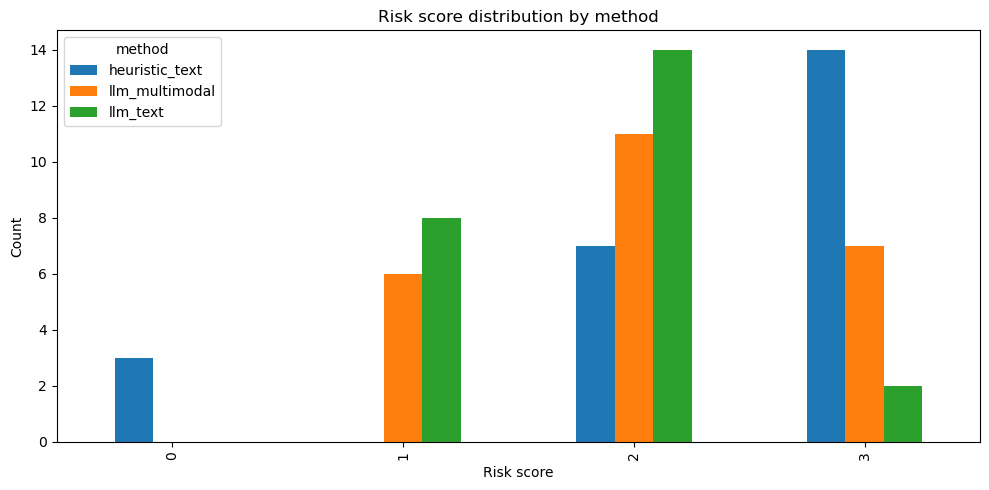

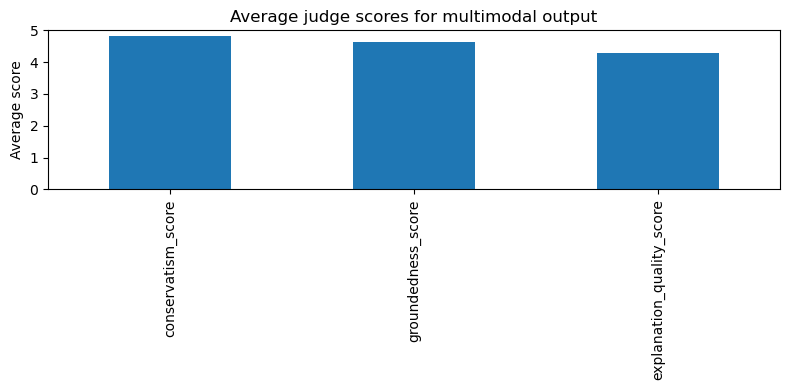

All outputs saved inside: project_results


,method,n,claim_rate,avg_risk,avg_evidence_count
0,heuristic_text,24,0.875,2.333333,1.916667
1,llm_multimodal,24,1.000,2.041667,2.708333
2,llm_text,24,1.000,1.750000,2.750000


,sample_id,text_claim_detected,text_specificity,text_risk_score,text_raw_json,mm_claim_detected,mm_specificity,mm_risk_score,mm_raw_json,claim_changed,specificity_changed,risk_delta,image_added_value_flag
21,P022,True,specific,1,"{""claim_detected"": true, ""claim_modalities"": [...",True,mixed,3,"{""claim_detected"": true, ""claim_modalities"": [...",False,True,2,True
0,P001,True,mixed,2,"{""claim_detected"": true, ""claim_modalities"": [...",True,mixed,3,"{""claim_detected"": true, ""claim_modalities"": [...",False,False,1,True
22,P023,True,mixed,2,"{""claim_detected"": true, ""claim_modalities"": [...",True,mixed,3,"{""claim_detected"": true, ""claim_modalities"": [...",False,False,1,True
3,P004,True,mixed,2,"{""claim_detected"": true, ""claim_modalities"": [...",True,mixed,3,"{""claim_detected"": true, ""claim_modalities"": [...",False,False,1,True
4,P005,True,specific,1,"{""claim_detected"": true, ""claim_modalities"": [...",True,mixed,2,"{""claim_detected"": true, ""claim_modalities"": [...",False,True,1,True


In [25]:
plot_risk_distribution(results_df)
plot_judge_scores(judge_df)

save_all(
    sample_df,
    results_df,
    comparison_df,
    judge_df=judge_df,
    gold_metrics_df=gold_metrics_df
)

print("All outputs saved inside:", RESULTS_DIR)

summary_table = (
    results_df.groupby("method")
    .agg(
        n=("sample_id", "count"),
        claim_rate=("claim_detected", "mean"),
        avg_risk=("risk_score", "mean"),
        avg_evidence_count=("evidence_count", "mean")
    )
    .reset_index()
)

display(summary_table)

case_candidates = comparison_df.sort_values("risk_delta", ascending=False).head(5)
display(case_candidates)

## 8. Inspect case studies for the report

In [26]:
# Rank the best case studies

mm_results = results_df[results_df["method"] == "llm_multimodal"][
    ["sample_id", "claim_detected", "specificity", "risk_score", "evidence_count", "reasoning_summary"]
].copy()

case_rank_df = comparison_df.merge(
    judge_df[["sample_id", "groundedness_score", "conservatism_score", "explanation_quality_score"]],
    on="sample_id",
    how="left"
).merge(
    mm_results,
    on="sample_id",
    how="left"
)


if "gold_df" in globals():
    case_rank_df = case_rank_df.merge(
        gold_df[["sample_id", "gold_claim_detected", "gold_specificity", "gold_risk_score"]],
        on="sample_id",
        how="left"
    )

    case_rank_df["gold_claim_match"] = (
        case_rank_df["claim_detected"] == case_rank_df["gold_claim_detected"]
    ).fillna(False)

    case_rank_df["gold_specificity_match"] = (
        case_rank_df["specificity"] == case_rank_df["gold_specificity"]
    ).fillna(False)

    case_rank_df["gold_risk_abs_error"] = (
        case_rank_df["risk_score"] - case_rank_df["gold_risk_score"]
    ).abs()
else:
    case_rank_df["gold_claim_match"] = False
    case_rank_df["gold_specificity_match"] = False
    case_rank_df["gold_risk_abs_error"] = 99

case_rank_df["judge_avg"] = case_rank_df[
    ["groundedness_score", "conservatism_score", "explanation_quality_score"]
].mean(axis=1)

case_rank_df["case_score"] = (
    case_rank_df["image_added_value_flag"].astype(int) * 3
    + case_rank_df["claim_changed"].astype(int) * 2
    + case_rank_df["specificity_changed"].astype(int) * 2
    + case_rank_df["risk_delta"].abs()
    + case_rank_df["judge_avg"]
    + case_rank_df["gold_claim_match"].astype(int) * 2
    + case_rank_df["gold_specificity_match"].astype(int) * 1
    - case_rank_df["gold_risk_abs_error"].clip(upper=3)
)

ranked_cases = case_rank_df.sort_values(
    ["case_score", "judge_avg", "risk_delta"],
    ascending=[False, False, False]
)

display(
    ranked_cases[
        [
            "sample_id",
            "case_score",
            "image_added_value_flag",
            "claim_changed",
            "specificity_changed",
            "risk_delta",
            "judge_avg",
            "gold_claim_match",
            "gold_specificity_match",
            "gold_risk_abs_error",
            "risk_score",
            "specificity",
            "reasoning_summary",
        ]
    ].head(10)
)

,sample_id,case_score,image_added_value_flag,claim_changed,specificity_changed,risk_delta,judge_avg,gold_claim_match,gold_specificity_match,gold_risk_abs_error,risk_score,specificity,reasoning_summary
21,P022,13.000000,True,False,True,2,4.000000,True,True,1,3,mixed,The product makes several explicit sustainabil...
4,P005,12.000000,True,False,True,1,4.000000,True,True,1,2,mixed,The product makes explicit sustainability clai...
6,P007,11.333333,True,False,False,1,4.333333,True,True,0,3,mixed,The product makes explicit sustainability clai...
5,P006,11.000000,True,False,False,1,4.000000,True,True,0,3,mixed,The product packaging and text contain several...
3,P004,10.000000,True,False,False,1,4.000000,True,True,1,3,mixed,The product makes several explicit sustainabil...
7,P008,9.666667,True,False,False,1,4.666667,True,True,2,2,specific,"The product makes clear, specific claims about..."
23,P024,9.666667,True,False,True,0,4.666667,True,True,3,2,specific,The product packaging explicitly claims the us...
0,P001,9.333333,True,False,False,1,4.333333,True,False,1,3,mixed,The product makes several sustainability-relat...
17,P018,9.000000,True,False,False,-1,5.000000,True,True,3,1,specific,"The product makes clear, specific claims about..."
10,P011,8.666667,True,False,True,0,4.666667,True,False,3,2,mixed,The product packaging and text explicitly clai...


In [27]:
show_case("P022", sample_df, results_df)

P022 | Almond Drink | Bio Organic
----------------------------------------------------------------------------------------------------
Product name: Almond Drink
Brand: Bio Organic
Generic name: Bon Organic Almond drink Sugar-free plant-based
Ingredients: water, 2,3% almonds', maltodextrins', sea salt, stabilizers: carob seed flour, gellanic gum, emulsifier: sunflower lecithin', natural aroma, 'from organic farming
Labels: Low or no sugar,Vegetarian,No gluten,Organic,EU Organic,Non-EU Agriculture,Vegan,100% vegetable,EU Agriculture,EU/non-EU Agriculture,European Vegetarian Union,European Vegetarian Union Vegan,FSC,FSC Mix,IT-BIO-009,No added sugar,No lactose,No sugar,Nutriscore,Nutriscore Grade B,Veganok,Triman,de:nachhaltige-verpackt,de:ressourcen-schützen,V-label
Categories: Beverages and beverages preparations,Plant-based foods and beverages,Beverages,Plant-based foods,Dairy substitutes,Milk substitutes,Nuts and their products,Plant-based beverages,Plant-based milk alternatives,Nut-

In [28]:
show_case("P005", sample_df, results_df)

P005 | Boisson à l’avoine | Alpro
----------------------------------------------------------------------------------------------------
Product name: Boisson à l’avoine
Brand: Alpro
Generic name: Boisson à l'avoine avec calcium et vitamines ajoutés
Ingredients: Eau, avoine 10%, huile de tournesol, calcium, fibres de chicorée, sel marin de table, stabilisant : gomme gellane, iodure de potassium, vitamines B2, B9, D2
Labels: Végétarien,Sans conservateurs,Source de fibres alimentaires,Végétalien,100% végétal,Source de calcium,Entreprise B certifiée,Agriculture UE,Union Végétarienne Européenne,Union Végétarienne Européenne Végétalien,FSC,FSC Mix,Point Vert,Riche en fibres,Sans sucre ajouté,Sans colorants,Sans lactose,Sans acides gras trans,Nutriscore,Nutriscore A,Riche en vitamine B,Source de vitamine B12,Source de vitamine D,À l'huile de tournesol,Sans ajout de produit laitiers,Sans édulcorants,Triman,Vegan Cert
Categories: Boissons et préparations de boissons,Aliments et boissons à base d

In [29]:
show_case("P018", sample_df, results_df)

P018 | Galettes boulghour & épeautre | Céréal Bio
----------------------------------------------------------------------------------------------------
Product name: Galettes boulghour & épeautre
Brand: Céréal Bio
Generic name: Spécialité végétale à base de blé et d'épeautre, issue de l'agriculture biologique
Ingredients: Boulgour de blé complet réhydraté 43,5%, petit épeautre cuit (blé) 13,2%, carottes 6%, farine de blé 5,1%, oignons 4,6%, huiles végétales (huile de tournesol oléique, huile de tournesol), concentré de tomates 3,9%, flocons d'avoine complète 3,7%, poivrons rouges 3,2%, gluten de blé 2,8%, flocons de blé complet 2,3%, céleri rave 14%, ail, raisins secs, sel de mer, épices.
Labels: Organic,Vegetarian,Certified by Ecocert,EU Organic,No preservatives,Non-EU Agriculture,Source of fibre,Vegan,Cooked in France,ES-ECO-019-CT,EU Agriculture,EU/non-EU Agriculture,FR-BIO-01,High fibres,Natural colorings,No additives,No colorings,Nutriscore,Nutriscore Grade A,AB Agriculture Biologi

In [30]:
show_case("P007", sample_df, results_df)

P007 | Geröstete Mandel Ohne Zucker | alpro
----------------------------------------------------------------------------------------------------
Product name: Geröstete Mandel Ohne Zucker
Brand: alpro
Generic name: Mandeldrink, angereichert mit Calcium und Vitaminen
Ingredients: Wasser, _Mandeln_ (2,3%), Calcium (Calciumcarbonat), Meersalz, Stabilisatoren (Guarkernmehl, Gellan), Emulgator (Lecithine), natürliches Aroma, Vitamine B12, D2, E.
Labels: Peu ou pas de matière grasse,Peu ou pas de sucre,Végétarien,Peu de matière grasse,Sans gluten,Sans lait,Sans conservateurs,Végétalien,Source de calcium,Entreprise B certifiée,Union Végétarienne Européenne,Union Végétarienne Européenne Végétalien,FSC,FSC Mix,Faible teneur en graisses saturées,Sans colorants,Sans colorants ou conservateurs,Sans sucre,Nutriscore,Nutriscore B,À base de plantes,The Vegan Society,Sans édulcorants,Triman
Categories: Boissons et préparations de boissons,Aliments et boissons à base de végétaux,Boissons,Aliments d'ori

In [31]:
def export_case_report_txt(sample_id: str, sample_df: pd.DataFrame, results_df: pd.DataFrame, output_dir: str = RESULTS_DIR):
    os.makedirs(output_dir, exist_ok=True)

    product = sample_df[sample_df["sample_id"] == sample_id].iloc[0]
    case_rows = results_df[results_df["sample_id"] == sample_id].copy()

    text_path = os.path.join(output_dir, f"{sample_id}_case_report.txt")

    lines = []
    lines.append("=" * 100)
    lines.append(f"SAMPLE ID: {sample_id}")
    lines.append(f"PRODUCT: {product.get('product_name', '')}")
    lines.append(f"BRAND: {product.get('brands', '')}")
    lines.append(f"QUERY: {product.get('query', '')}")
    lines.append(f"IMAGE URL: {product.get('image_url', '')}")
    lines.append("-" * 100)
    lines.append("TEXT BLOB:")
    lines.append(product.get("text_blob", ""))
    lines.append("-" * 100)

    for _, row in case_rows.iterrows():
        lines.append(f"METHOD: {row['method']}")
        lines.append(f"CLAIM DETECTED: {row['claim_detected']}")
        lines.append(f"CLAIM MODALITIES: {row['claim_modalities']}")
        lines.append(f"CLAIM TYPES: {row['claim_types']}")
        lines.append(f"SPECIFICITY: {row['specificity']}")
        lines.append(f"EVIDENCE STRENGTH: {row['evidence_strength']}")
        lines.append(f"RISK SCORE: {row['risk_score']}")
        lines.append(f"RISK LABEL: {row['risk_label']}")
        lines.append(f"EVIDENCE COUNT: {row['evidence_count']}")
        lines.append(f"REASONING SUMMARY: {row['reasoning_summary']}")
        lines.append("RAW JSON:")
        lines.append(json.dumps(json.loads(row["raw_json"]), ensure_ascii=False, indent=2))
        lines.append("-" * 100)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"Saved: {text_path}")

In [32]:
export_case_report_txt("P022", sample_df, results_df)
export_case_report_txt("P005", sample_df, results_df)
export_case_report_txt("P018", sample_df, results_df)

Saved: project_results\P022_case_report.txt
Saved: project_results\P005_case_report.txt
Saved: project_results\P018_case_report.txt
